## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

In [2]:
df = pd.read_csv('../data/golub.csv')
df['cancer'] = df['cancer'].replace(['allB', 'allT', 'aml'], [0, 0, 1])
df.head()

/tmp/ipykernel_6827/3936843382.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['cancer'] = df['cancer'].replace(['allB', 'allT', 'aml'], [0, 0, 1])


,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,0,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,0,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,0,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,0,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,0,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

In [3]:
y = df['cancer'].to_numpy()
x = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer'], axis=1).to_numpy()

In [4]:
model = LinearRegression()
model.fit(x, y)
yhat = model.predict(x)

In [5]:
mse = np.sum( (y - yhat)**2 ) / len(y)
print('mean squared error is', mse)

mean squared error is 1.737616794269373e-30


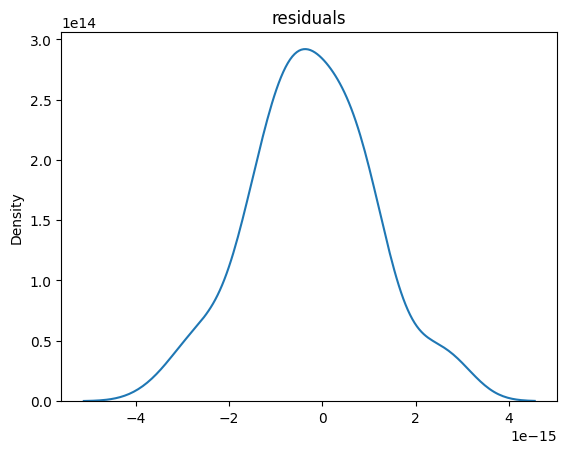

In [6]:
residuals = yhat - y
sns.kdeplot(residuals)
plt.title('residuals')
plt.show()

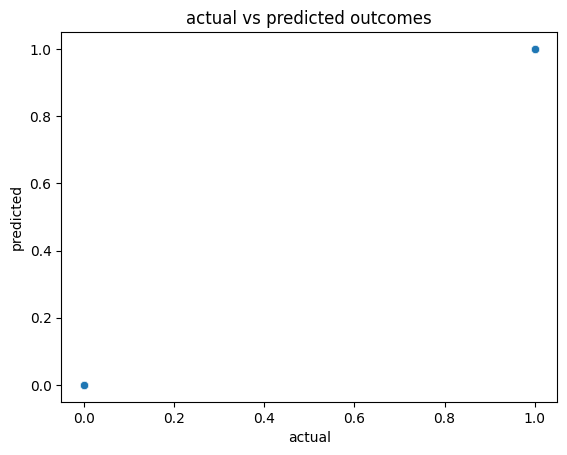

In [7]:
sns.scatterplot(x=y, y=yhat)
plt.title('actual vs predicted outcomes')
plt.xlabel('actual')
plt.ylabel('predicted')
plt.show()

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

In [8]:
kfold = KFold(n_splits=10, shuffle=True, random_state=100)

scores = cross_val_score(model, x, y, cv=kfold, scoring="neg_mean_squared_error")
scores = -scores

print("fold scores:", scores)
print("mean score:", np.mean(scores))
print("median score:", np.median(scores))
print("std dev:", np.std(scores))

fold scores: [0.02265367 0.04875751 0.06347474 0.06304086 0.09383082 0.08300696
 0.0207161  0.01969831 0.02087605 0.02271393]
mean score: 0.04587689508852555
median score: 0.03573571993995744
std dev: 0.027037144984588105


Without cross validation, the training error is very very close to zero. With cross validation, however, the error is about 0.04 on average. This means that the model has high variance and low bias. OLS is very unstable out of sample, and it overfits. The cross validation shows this.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

In [9]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(x)

alpha_grid = np.logspace(-4, -2, num=50)
lasso_cv = LassoCV(cv=10, alphas=alpha_grid, random_state=100, max_iter=10000)
lasso_cv.fit(X_sc, y)

alpha_star = lasso_cv.alpha_
mean_mse_path = np.mean(lasso_cv.mse_path_, axis=1)
index_star = np.argmin(mean_mse_path)

coefs = []
for alpha in lasso_cv.alphas_:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_sc, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

coefs_star = coefs[index_star]
selected_idx = np.nonzero(coefs_star)[0]
selected_genes = df.columns[selected_idx].tolist()

lasso_star = Lasso(alpha=alpha_star, max_iter=10000).fit(X_sc, y)
y_hat_lasso = lasso_star.predict(X_sc)

print(f'Optimal alpha: {alpha_star:.10f}')
print(f'Selected genes: {len(selected_genes)}')
print(f'Discarded genes: {x.shape[1] - len(selected_genes)}')
selected_genes


Optimal alpha: 0.0016768329
Selected genes: 70
Discarded genes: 7059


['AD001527_cds1_at',
 'AF005043_at',
 'D26362_at',
 'D29642_at',
 'D38555_at',
 'D50645_at',
 'D86976_at',
 'HG1872-HT1907_at',
 'J04040_at',
 'J04101_at',
 'L12723_at',
 'M16973_at',
 'M18737_rna1_at',
 'M20471_at',
 'M22632_at',
 'M22919_rna2_at',
 'M27160_at',
 'M27288_at',
 'M28211_at',
 'M31651_at',
 'M34079_at',
 'M62831_at',
 'M83751_at',
 'M94556_at',
 'M95724_at',
 'M97925_rna1_at',
 'U10485_at',
 'U14407_at',
 'U30246_at',
 'U34252_at',
 'U35735_at',
 'U46499_at',
 'U49869_rna1_at',
 'U50929_at',
 'U59863_at',
 'U82256_at',
 'U82468_at',
 'U89355_at',
 'X03656_rna1_at',
 'X14346_at',
 'X16416_at',
 'X52773_at',
 'X56468_at',
 'X63578_rna1_at',
 'X66397_at',
 'X68733_rna1_at',
 'X81003_at',
 'X82877_at',
 'X95406_at',
 'X95826_at',
 'Y00970_at',
 'Y07595_at',
 'Y09980_rna4_at',
 'Y11710_rna1_at',
 'M85289_at',
 'X52228_at',
 'Y12393_s_at',
 'D26155_s_at',
 'HG1327-HT1327_s_at',
 'U89922_s_at',
 'M10321_s_at',
 'X03363_s_at',
 'U59058_s_at',
 'M20203_s_at',
 'M24485_s_at',
 'U2

70 genes are kept and 7059 are discarded. The selected genes are `AD001527_cds1_at`,
 `AF005043_at`,
 `D26362_at`,
 `D29642_at`,
 `D38555_at`,
 `D50645_at`,
 `D86976_at`,
 `HG1872-HT1907_at`,
 `J04040_at`,
 `J04101_at`,
 `L12723_at`,
 `M16973_at`,
 `M18737_rna1_at`,
 `M20471_at`,
 `M22632_at`,
 `M22919_rna2_at`,
 `M27160_at`,
 `M27288_at`,
 `M28211_at`,
 `M31651_at`,
 `M34079_at`,
 `M62831_at`,
 `M83751_at`,
 `M94556_at`,
 `M95724_at`,
 `M97925_rna1_at`,
 `U10485_at`,
 `U14407_at`,
 `U30246_at`,
 `U34252_at`,
 `U35735_at`,
 `U46499_at`,
 `U49869_rna1_at`,
 `U50929_at`,
 `U59863_at`,
 `U82256_at`,
 `U82468_at`,
 `U89355_at`,
 `X03656_rna1_at`,
 `X14346_at`,
 `X16416_at`,
 `X52773_at`,
 `X56468_at`,
 `X63578_rna1_at`,
 `X66397_at`,
 `X68733_rna1_at`,
 `X81003_at`,
 `X82877_at`,
 `X95406_at`,
 `X95826_at`,
 `Y00970_at`,
 `Y07595_at`,
 `Y09980_rna4_at`,
 `Y11710_rna1_at`,
 `M85289_at`,
 `X52228_at`,
 `Y12393_s_at`,
 `D26155_s_at`,
 `HG1327-HT1327_s_at`,
 `U89922_s_at`,
 `M10321_s_at`,
 `X03363_s_at`,
 `U59058_s_at`,
 `M20203_s_at`,
 `M24485_s_at`,
 `U23852_s_at`,
 `U40271_s_at`,
 `J00210_rna1_at`,
 `U66061_cds3_at`, and
 `U47677_at`.

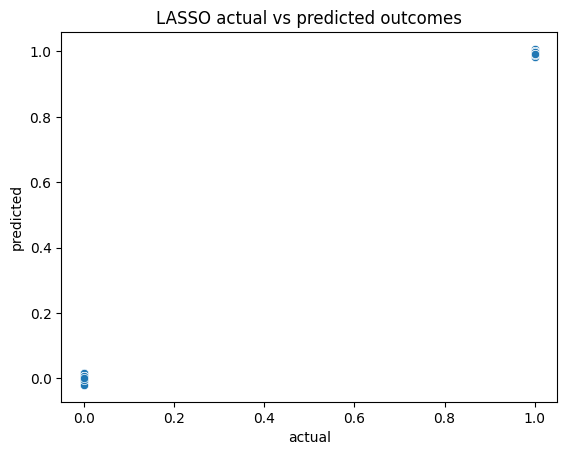

In [10]:
sns.scatterplot(x=y, y=y_hat_lasso)
plt.title('LASSO actual vs predicted outcomes')
plt.xlabel('actual')
plt.ylabel('predicted')
plt.show()

In [11]:
lasso_mse = np.mean((y-y_hat_lasso)**2)
print('lasso mse:', lasso_mse)

lasso mse: 4.6427944164777185e-05


5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

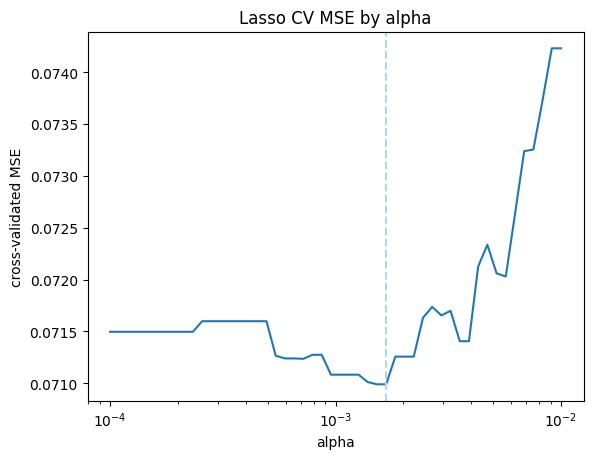

In [12]:
sns.lineplot(x=lasso_cv.alphas_, y=mean_mse_path)
plt.axvline(alpha_star, color='lightblue', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('cross-validated MSE')
plt.title('Lasso CV MSE by alpha')
plt.show()

For alpha values that are too small (to the left of the vertical line), the model is underfitting. For alpha values that are too big (to the right of the vertical line), the model is overfitting. The optimal alpha value is about 0.0016768329.

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

The linear regression model was overfit to the training data. It functioned the same as memorizing the data and then performing lookups when prompted. The LASSO method, however, actually found which variables were important by shrinking unnecessary coefficients to zero. It used those important variables to find better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

There are a lot of variables present in health and particularly in genetics. Humans have thousands and thousands of genes, so feature spaces can get very complex very fast. Regularization methods help simplify this; they help us isolate which variables are actually important.

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

Using LASSO and other models for health is risky because of the potential consequences when things do go wrong. Health is pretty fragile, so any mistakes can have big impacts. Additonally, our model only shows correlations, not causations. We cannot say that one gene change causes one illness. Thus, we should be cautious of using the model to lead to physical (eg. surgical) interventions that can cause bad things.